In [1]:
import torch
from check import setup_torch
# Dummy image-like data: batch=4, channels=1, height=256, width=256
data_dummy = torch.randn(4, 1, 256, 256, dtype=torch.float32)

device = setup_torch()
data_dummy.shape


✅ Using CUDA globally
GPU: NVIDIA GeForce RTX 4090


torch.Size([4, 1, 256, 256])

In [2]:
data_tensor = torch.load("../../json_data/dataset_updated.pt", map_location=device)
data_tensor = [t.flatten() for t in data_tensor]
data_tensor = [t.reshape((128,1000)) for t in data_tensor]
data_tensor = torch.stack(data_tensor)
data_tensor.shape

torch.Size([1532, 128, 1000])

In [ ]:
from models.Data_Load import DataLoader_AutoEncoder, Dataset_

dataset = Dataset_(data_tensor,normalize=True)

train_size = 1200
test_size = len(dataset) - train_size
gen = torch.Generator(device=device)
train_dataset, test_dataset = torch.utils.data.random_split(
    dataset, [train_size, test_size], generator=gen
)

dataLoader = DataLoader_AutoEncoder(train_dataset, batch_size=40, shuffle=True)
dataLoader_test = DataLoader_AutoEncoder(test_dataset, batch_size=30, shuffle=False)

In [4]:
from models.Autencoder import AutoEncoder

latent_model = AutoEncoder()
latent_model.to(device)



Loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(latent_model.parameters(), lr=1e-3)
num_epochs = 300
for epoch in range(num_epochs):
    for batch in dataLoader:
        
        batch = batch.to(device)
        output = latent_model(batch)
        loss = Loss_fn(output, batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")


OutOfMemoryError: CUDA out of memory. Tried to allocate 3.82 GiB. GPU 0 has a total capacity of 23.51 GiB of which 2.43 GiB is free. Process 4779 has 52.09 MiB memory in use. Including non-PyTorch memory, this process has 20.53 GiB memory in use. Of the allocated memory 19.11 GiB is allocated by PyTorch, and 1007.87 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [4]:

def test_model(model, dataLoader, Loss_fn, optimizer, num_epochs):

    model.eval()
    total_mse = 0.0
    total_mae = 0.0
    num_batches = 0

    output_data = []

    with torch.no_grad():
        for batch in dataLoader:
            batch = batch.to(device)
            output = model(batch)
            total_mse += Loss_fn(output, batch).item()
            total_mae += torch.mean(torch.abs(output - batch)).item()
            num_batches += 1
            output_data.append(output.cpu().numpy())
        

    avg_mse = total_mse / max(1, num_batches)
    avg_mae = total_mae / max(1, num_batches)
    return avg_mse,avg_mae

In [5]:
def plot_(X,Y,x_label='Index',y_label='Value',title='Output Data Plot'):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 5))
    plt.plot(X, Y, marker='o')
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.grid()
    plt.show()

# Example usage:
# Assuming output_data is a list of numpy arrays, we can plot the first one

In [6]:
def train(epoch, lr_rate,dataLoader,Loss_fn, optimizer):
    from models.Autencoder import AutoEncoder

    latent_model = AutoEncoder()
    latent_model.to(device)


    if Loss_fn == "MSE":
        Loss_fn = torch.nn.MSELoss()
    elif Loss_fn == "MAE":
        Loss_fn = torch.nn.L1Loss()
    elif Loss_fn == "BCE":
        Loss_fn = torch.nn.BCEWithLogitsLoss()
    else:
        raise ValueError("Invalid Loss Function")
    if optimizer == "Adam":
        optimizer = torch.optim.Adam(latent_model.parameters(), lr=lr_rate )
    elif optimizer == "AdamW":
        optimizer = torch.optim.AdamW(latent_model.parameters(), lr=lr_rate )
    elif optimizer == "SGD":
        optimizer = torch.optim.SGD(latent_model.parameters(), lr=lr_rate )
    else:
        raise ValueError("Invalid Optimizer")
    num_epochs = epoch
    for epoch in range(num_epochs):
        for batch in dataLoader:
            
            batch = batch.to(device)
            output = latent_model(batch)
            loss = Loss_fn(output, batch)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")
    return latent_model, Loss_fn, optimizer, num_epochs


In [24]:
lr_rate_list = [4e-3,5e-3,1e-2,2e-2,4e-2,5e-2] 
Loss_fn_list = ["MSE", "MAE", "BCE"]
optimizer_list = ["Adam"]

output_mse = {}
output_mae = {}
epoch = 200

for lr_rate in lr_rate_list:
    for Loss_ in Loss_fn_list:
        for optimizer_ in optimizer_list:
            print(f"Training with learning rate: {lr_rate}, Loss Function: {Loss_}, Optimizer: {optimizer_}")
            latent_model, Loss_fn, optimizer, num_epochs = train(epoch, lr_rate, dataLoader, Loss_, optimizer_  )
            avg_loss, avg_mae = test_model(latent_model, dataLoader_test, Loss_fn, optimizer, num_epochs)
            if f"{Loss_}_{optimizer_}" not in output_mse:
                output_mse[f"{Loss_}_{optimizer_}"] = []
            output_mse[f"{Loss_}_{optimizer_}"].append(avg_loss)


Training with learning rate: 0.004, Loss Function: MSE, Optimizer: Adam
Epoch [1/200], Loss: 0.0500
Epoch [2/200], Loss: 0.0420
Epoch [3/200], Loss: 0.0387
Epoch [4/200], Loss: 0.0271
Epoch [5/200], Loss: 0.0213
Epoch [6/200], Loss: 0.0218
Epoch [7/200], Loss: 0.0233
Epoch [8/200], Loss: 0.0206
Epoch [9/200], Loss: 0.0216
Epoch [10/200], Loss: 0.0251
Epoch [11/200], Loss: 0.0225
Epoch [12/200], Loss: 0.0199
Epoch [13/200], Loss: 0.0209
Epoch [14/200], Loss: 0.0215
Epoch [15/200], Loss: 0.0257
Epoch [16/200], Loss: 0.0218
Epoch [17/200], Loss: 0.0233
Epoch [18/200], Loss: 0.0191
Epoch [19/200], Loss: 0.0189
Epoch [20/200], Loss: 0.0187
Epoch [21/200], Loss: 0.0249
Epoch [22/200], Loss: 0.0246
Epoch [23/200], Loss: 0.0228
Epoch [24/200], Loss: 0.0243
Epoch [25/200], Loss: 0.0188
Epoch [26/200], Loss: 0.0233
Epoch [27/200], Loss: 0.0211
Epoch [28/200], Loss: 0.0190
Epoch [29/200], Loss: 0.0214
Epoch [30/200], Loss: 0.0242
Epoch [31/200], Loss: 0.0218
Epoch [32/200], Loss: 0.0225
Epoch [33

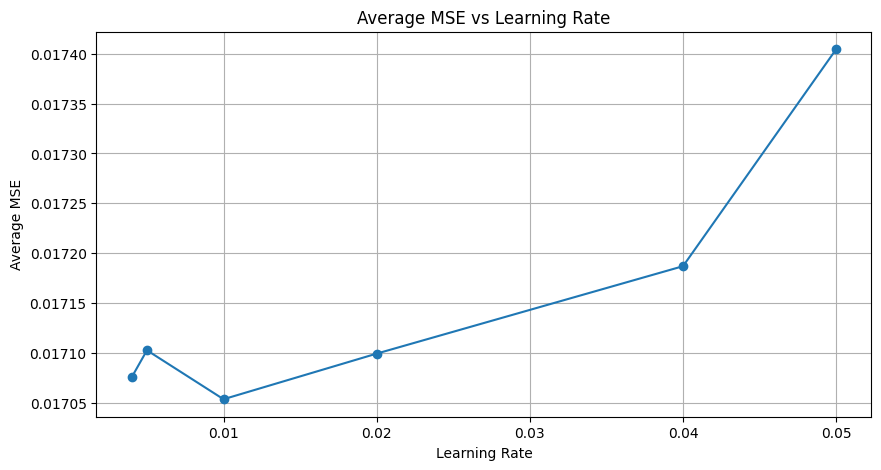

In [27]:
plot_(lr_rate_list, output_mse["MSE_Adam"], x_label='Learning Rate', y_label='Average MSE', title='Average MSE vs Learning Rate')


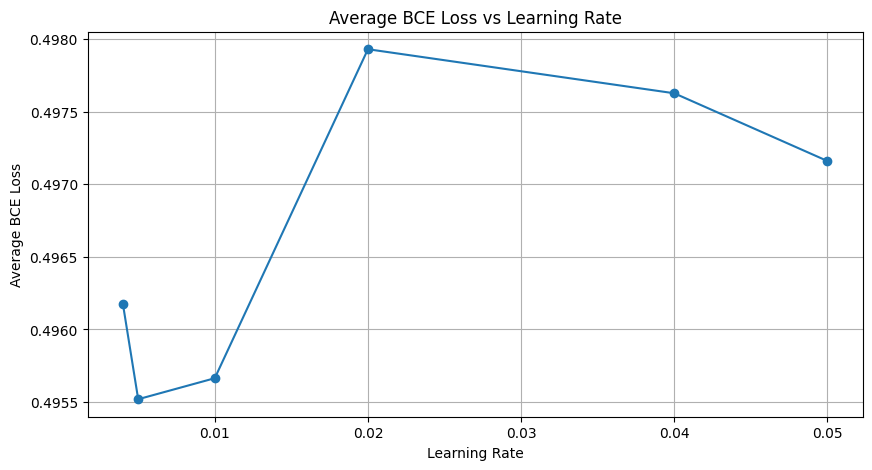

In [28]:
plot_(lr_rate_list, output_mse["BCE_Adam"], x_label='Learning Rate', y_label='Average BCE Loss', title='Average BCE Loss vs Learning Rate')


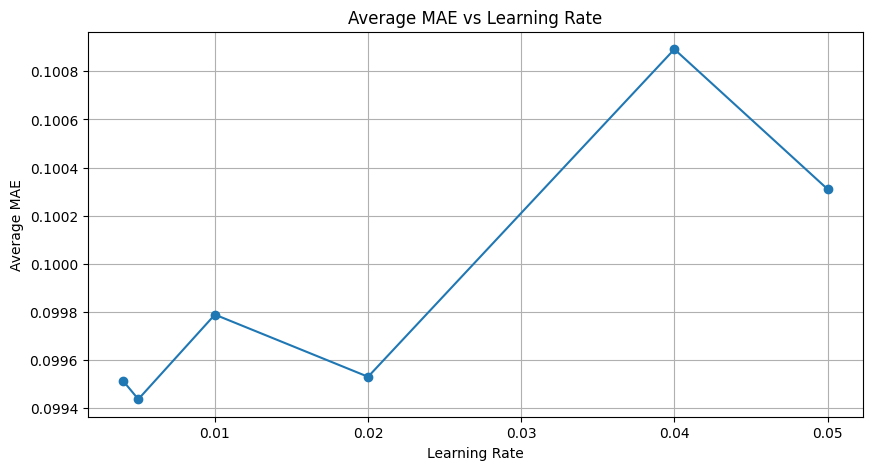

In [29]:
plot_(lr_rate_list, output_mse["MAE_Adam"], x_label='Learning Rate', y_label='Average MAE', title='Average MAE vs Learning Rate')


### LR choice
We can therefore see that the best lr would be 0.005-0.02 this would thus be our choice for the model

In [7]:
lr_rate = 0.01
epoch = 1000
latent_model, Loss_fn, optimizer, num_epochs = train(epoch, lr_rate, dataLoader,Loss_fn="MSE", optimizer="Adam")



ValueError: num_channels (1) must be divisible by num_groups (8)

In [77]:
from matplotlib import pyplot as plt
import matplotlib as mpl


data1 = dataLoader.dataset[0][0]
data1_latent = latent_model.encode_latent(dataLoader.dataset[0].unsqueeze(0))
data_reconstructed = latent_model.decode_latent(data1_latent)[0][0]
data1_latent.shape, data1.shape,data_reconstructed.shape


(torch.Size([1, 128, 2, 15]), torch.Size([128, 1000]), torch.Size([128, 1000]))

(torch.Size([128, 1000]), torch.Size([128, 1000]))

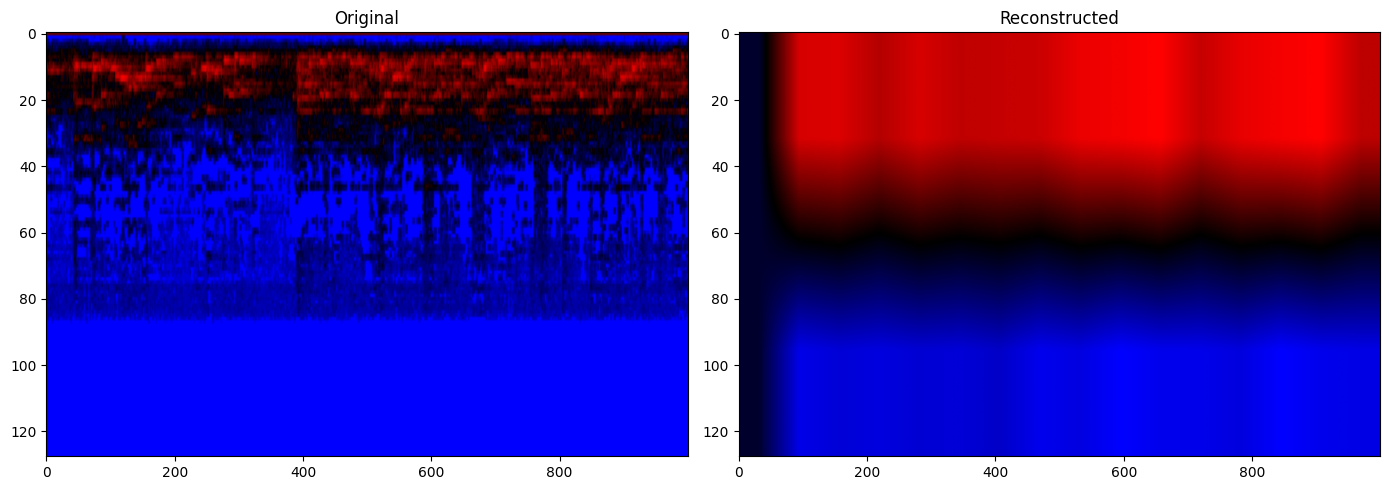

In [79]:
data1_cpu = data1.detach().cpu()
data_reconstructed_cpu = data_reconstructed.detach().cpu()
cmap = cmap2 = mpl.colors.LinearSegmentedColormap.from_list('my_colormap', ['blue', 'black', 'red'], 256)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(data1_cpu, cmap=cmap, aspect='auto')
axes[0].set_title('Original')
axes[1].imshow(data_reconstructed_cpu, cmap=cmap, aspect='auto')
axes[1].set_title('Reconstructed')
plt.tight_layout()
data1_cpu.shape, data_reconstructed_cpu.shape